# **📩 Spam Metin Sınıflandırma (NLP Uygulaması)**

Bu çalışmada, RNN tabanlı modeller kullanarak bir spam mesaj sınıflandırıcı geliştireceksiniz.

Veri seti:

1. sütun → Etiket (spam / ham)
2. sütun → Mesaj metni

**🧪 Kullanılacak Yöntemler**

Bu çalışmada aşağıdaki teknikleri uygulayacaksınız:

Embedding (Gömme katmanı)
SimpleRNN
GRU
LSTM
Ensemble Model (Model birleştirme)

**⚙️ Veri Ön İşleme**

Model eğitimi öncesinde metin verisi üzerinde şu işlemleri uygulayacaksınız:

**Tokenization →** Metinleri sayısal ifadelere dönüştürme

**Padding →** Tüm dizileri aynı uzunluğa getirme

📌 Bu adımlar, metin verisinin sinir ağına girdi olarak verilebilmesi için zorunludur.

**📌 Not:**

Detaylı katman açıklamaları için aşağıdaki dokümantasyonları inceleyebilirsiniz:

SimpleRNN: https://keras.io/api/layers/recurrent_layers/simple_rnn/

LSTM: https://keras.io/api/layers/recurrent_layers/lstm/




# **Gerekli Kütüphaneler**

Bu bölümde, metin sınıflandırma problemi için kullanılacak temel kütüphaneleri içe aktarmanız beklenmektedir.

*   RNN tabanlı modeller için SimpleRNN, LSTM ve Embedding katmanlarına ihtiyacınız olacak
*   Veri işlemleri için pandas ve numpy kullanabilirsiniz
*   Görselleştirme için matplotlib ve seaborn tercih edilebilir





In [78]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# **Veri Setinin Yüklenmesi**

Bu adımda, spam mesaj sınıflandırma problemi için kullanılacak veri setini içe aktarmanız beklenmektedir.

👉 Görev:

`"datasets_2050_3494_SPAM text message 20170820 - Data"` isimli veri setini uygun bir yöntemle yükleyin

Veri setini bir DataFrame olarak saklayın

İlk birkaç satırı görüntüleyerek veri yapısını inceleyin

In [79]:
from google.colab import files
uploaded = files.upload()

Saving datasets_2050_3494_SPAM text message 20170820 - Data.csv to datasets_2050_3494_SPAM text message 20170820 - Data (2).csv


In [80]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [81]:
df.columns = ['label', 'text']
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [82]:
df['label'] = df['label'].map({'ham':0, 'spam':1})
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# **Veri Keşfi (Exploratory Analysis)**

*   Veri setinin ilk 20 satırını görüntüleyin
*   Veri setinde spam ve non-spam (ham) mesajların sayısını hesaplayın
*   Her iki sınıfın veri setindeki dağılımını gözlemleyin
*   Mesaj metinlerini bir liste/array yapısında toplayın
*   Etiketleri sayısal forma dönüştürün
*   ham → 0, spam → 1 olacak şekilde kodlayın
*   Metinler ve etiketlerin boyutlarını kontrol edin



In [83]:
df.head(20)

df['label'].value_counts()

texts = df['text'].values
labels = df['label'].values

print(texts.shape)
print(labels.shape)

(5572,)
(5572,)


In [84]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = 100
X = pad_sequences(sequences, maxlen=maxlen)

y = labels
X.shape

(5572, 100)

# **Metinlerin Sayısallaştırılması ve Sabit Uzunluğa Getirilmesi**

Bu aşamada metin verisini modele uygun hale getirmek için gerekli ön işleme adımlarını uygulamanız beklenmektedir.

**👉 Görev:**

Metinleri sayısal dizilere dönüştürmek için gerekli araçları içe aktarın

Sözlükte kullanılacak maksimum kelime sayısını belirleyin

Her mesaj için kullanılacak maksimum dizi uzunluğunu tanımlayın

**📌 İpucu:**

Tokenizer metinleri tamsayı dizilerine dönüştürmek için kullanılır

pad_sequences tüm dizileri aynı uzunluğa getirmek için kullanılır

Çok sık geçen kelimelere odaklanmak için kelime dağarcığını belirli bir üst sınırla kısıtlayabilirsiniz

In [85]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# maksimum kelime sayısı
max_words = 5000

# maksimum uzunluk
maxlen = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

X = pad_sequences(sequences, maxlen=maxlen)
y = labels

X.shape

(5572, 100)

# **Eğitim ve Test Verisinin Ayrılması**

Modeli eğitmek ve değerlendirmek için veri setini iki parçaya ayırmanız gerekmektedir.

**👉 Görev:**

Veri setinin yaklaşık %80’ini eğitim, kalanını test (validation) verisi olarak ayırın

Eğitim ve test veri sayılarının toplamının, veri setinin tamamına eşit olduğunu kontrol edin


📌 Not:
Gerçek uygulamalarda train / validation / test şeklinde üçlü ayrım tercih edilir, ancak bu çalışmada ikiye bölme yeterlidir.

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [87]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4457, 100)
(1115, 100)
(4457,)
(1115,)


# **Tokenization ve Padding Uygulaması**

Bu aşamada metin verisini modele girdi olarak verebilmek için gerekli dönüşümleri gerçekleştirmeniz beklenmektedir.

**👉 Görev:**

Metinleri kullanarak bir tokenizer oluşturun ve eğitin

Metinleri tamsayı dizilerine (sequences) dönüştürün

Veri setindeki benzersiz kelime sayısını inceleyin

Elde edilen dizileri sabit uzunluğa (maxlen) getirin

**📌 Dikkat:**

Padding işlemini varsayılan (pre-padding) ya da post olacak şekilde deneyebilirsiniz

Sonuçta oluşan veri boyutunun (örnek sayısı, maxlen) şeklinde olması gerekir

In [88]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# maksimum kelime sayısı
max_words = 5000

# maksimum uzunluk
maxlen = 100

# tokenizer oluştur
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)

# metinleri sayıya çevir
sequences = tokenizer.texts_to_sequences(texts)

# benzersiz kelime sayısı
print(len(tokenizer.word_index))

# padding
X = pad_sequences(sequences, maxlen=maxlen)

# boyut kontrolü
print(X.shape)

9004
(5572, 100)


# **Verinin Karıştırılması ve Bölünmesi**

Modelin daha sağlıklı öğrenebilmesi için verinin rastgele karıştırılması gerekmektedir.

**👉 Görev:**

Veri ve etiketleri aynı sırayı koruyacak şekilde karıştırın (shuffle)

Karıştırılmış veriyi daha önce belirlediğiniz oranlara göre eğitim ve test olarak ayırın

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# kontrol
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4457, 100)
(1115, 100)
(4457,)
(1115,)



# **Model Oluşturma (SimpleRNN)**
Bu aşamada, metin sınıflandırma problemi için bir RNN tabanlı model oluşturmanız beklenmektedir.

**👉 Görev:**

Sıralı bir model (Sequential) oluşturun

İlk katman olarak Embedding katmanı ekleyin

Ardından bir SimpleRNN katmanı kullanın

Çıkış için Dense + sigmoid aktivasyonlu bir katman ekleyin

**👉 Devamında:**

Modeli uygun loss ve optimizer ile derleyin

Eğitim verisi ile modeli eğitin

Eğitim sürecini (epoch, batch_size, validation) ayarlayın

 **📌 Not:Aynı mimariyi daha sonra GRU ve LSTM katmanları ile de kurarak performans karşılaştırması yapacaksınız.**

In [90]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential()

# Embedding
model.add(Embedding(input_dim=5000, output_dim=32, input_length=100))

# RNN
model.add(SimpleRNN(32))

# Çıkış katmanı
model.add(Dense(1, activation='sigmoid'))

# Derleme
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [91]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.9244 - loss: 0.2447 - val_accuracy: 0.9659 - val_loss: 0.1225
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9827 - loss: 0.0599 - val_accuracy: 0.9839 - val_loss: 0.0585
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9935 - loss: 0.0268 - val_accuracy: 0.9901 - val_loss: 0.0434
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9964 - loss: 0.0173 - val_accuracy: 0.9892 - val_loss: 0.0460
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9980 - loss: 0.0105 - val_accuracy: 0.9892 - val_loss: 0.0452


# **Model Performansının Görselleştirilmesi**

Model eğitildikten sonra performansını analiz etmek için eğitim sürecindeki metrikleri görselleştirmeniz gerekmektedir.

**👉 Görev:**

Eğitim sırasında elde edilen accuracy ve loss değerlerini alın

Hem training hem validation için:

Accuracy grafiği çizdirin

Loss grafiği çizdirin


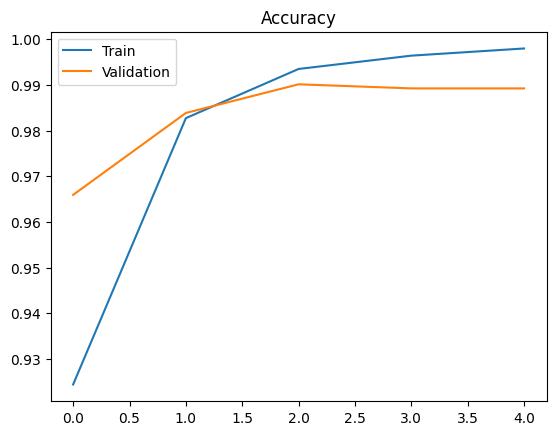

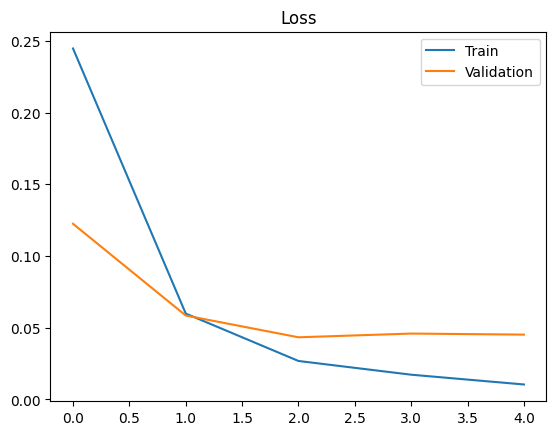

In [92]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# **Modelin Test Edilmesi ve Değerlendirilmesi**

Eğitilen modelin test verisi üzerindeki performansını değerlendirmeniz beklenmektedir.

**👉 Görev:**

Test verisi üzerinde modelin tahminlerini elde edin

Modelin loss ve accuracy değerlerini hesaplayın

Tahmin sonuçlarını analiz etmek için confusion matrix oluşturun

In [93]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9892 - loss: 0.0452
Test Loss: 0.045224856585264206
Test Accuracy: 0.9892376661300659


In [94]:
y_pred = model.predict(X_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [95]:
y_pred = (y_pred > 0.5).astype(int)

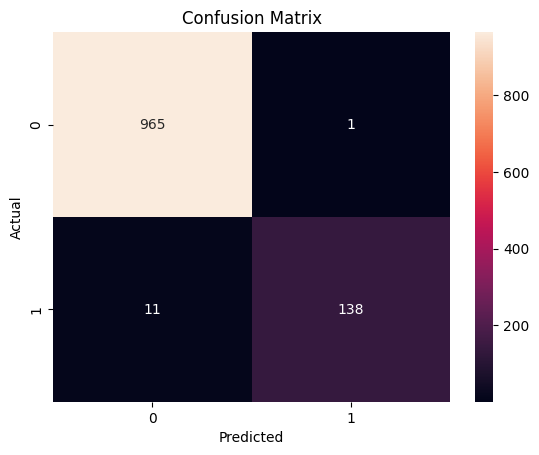

In [96]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **Model Oluşturma (GRU)**

Bu aşamada, önceki modele benzer yapıda bir GRU tabanlı metin sınıflandırma modeli geliştirmeniz beklenmektedir.

**👉 Görev:**

Sequential yapısını kullanarak yeni bir model oluşturun

İlk katmanda Embedding kullanın

Ardından GRU katmanı ekleyin

Çıkış katmanında Dense + sigmoid yapısını kullanın

**👉 Devamında:**

Modeli ikili sınıflandırmaya uygun şekilde derleyin

Eğitim verisi ile modeli eğitin

Eğitim sürecindeki performansı daha sonra SimpleRNN modeli ile karşılaştırı

In [97]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

gru_model = Sequential()

gru_model.add(Embedding(input_dim=5000, output_dim=32, input_length=100))
gru_model.add(GRU(32))
gru_model.add(Dense(1, activation='sigmoid'))

gru_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [98]:
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.9069 - loss: 0.2624 - val_accuracy: 0.9839 - val_loss: 0.0709
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.9863 - loss: 0.0485 - val_accuracy: 0.9919 - val_loss: 0.0480
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.9948 - loss: 0.0230 - val_accuracy: 0.9910 - val_loss: 0.0386
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9971 - loss: 0.0127 - val_accuracy: 0.9901 - val_loss: 0.0398
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.9987 - loss: 0.0070 - val_accuracy: 0.9901 - val_loss: 0.0461


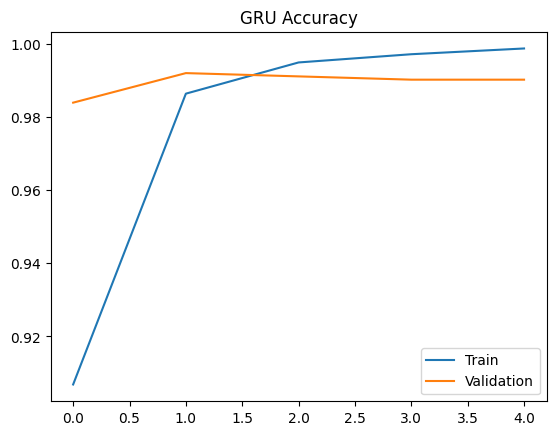

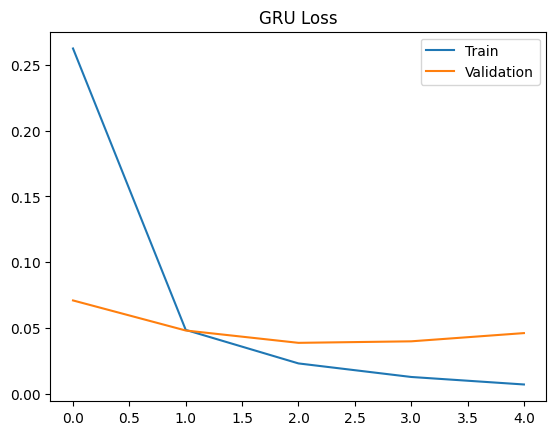

In [99]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history_gru.history['accuracy'])
plt.plot(history_gru.history['val_accuracy'])
plt.title('GRU Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])
plt.title('GRU Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# **GRU Modelinin Değerlendirilmesi**

Eğitilen GRU modelinin test verisi üzerindeki performansını analiz ediniz.

**👉 Görev:**

Test verisi için model tahminlerini elde edin

Modelin loss ve accuracy değerlerini hesaplayın

Sonuçları değerlendirmek için confusion matrix oluşturun

In [100]:
loss, accuracy = gru_model.evaluate(X_test, y_test)

print("GRU Test Loss:", loss)
print("GRU Test Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9901 - loss: 0.0461
GRU Test Loss: 0.04605306312441826
GRU Test Accuracy: 0.9901345372200012


In [101]:
y_pred_gru = gru_model.predict(X_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [102]:
y_pred_gru = (y_pred_gru > 0.5).astype(int)

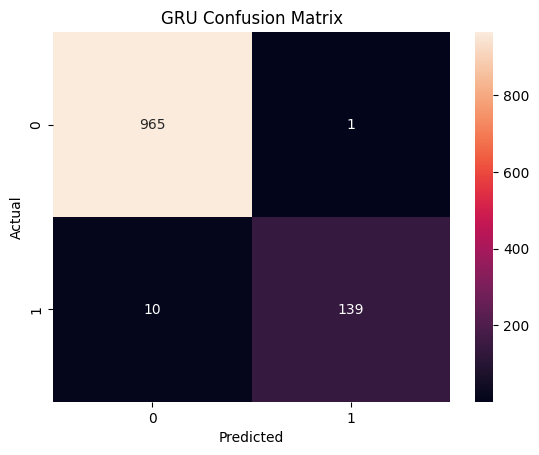

In [103]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_gru)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")
plt.show()

GRU modeli, SimpleRNN modeline göre daha iyi performans göstermiştir. Özellikle spam mesajların tespitinde hata sayısının azaldığı gözlemlenmiştir.

# **Model Oluşturma (LSTM)**

Bu aşamada, aynı mimariyi kullanarak bir LSTM tabanlı model geliştirmeniz beklenmektedir.

**👉 Görev:**

Sequential model yapısını kullanarak yeni bir model oluşturun

İlk katman olarak Embedding ekleyin

Tekrarlayan katman olarak LSTM kullanın

Çıkış katmanında Dense + sigmoid yapısını tanımlayın

**👉 Devamında:**

Modeli uygun loss ve optimizer ile derleyin

Eğitim verisi ile modeli eğitin

In [104]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential()

lstm_model.add(Embedding(input_dim=5000, output_dim=32, input_length=100))
lstm_model.add(LSTM(32))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [105]:
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9143 - loss: 0.2526 - val_accuracy: 0.9722 - val_loss: 0.1068
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9841 - loss: 0.0636 - val_accuracy: 0.9874 - val_loss: 0.0499
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9937 - loss: 0.0298 - val_accuracy: 0.9874 - val_loss: 0.0515
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9964 - loss: 0.0183 - val_accuracy: 0.9910 - val_loss: 0.0404
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9982 - loss: 0.0094 - val_accuracy: 0.9928 - val_loss: 0.0354


# **LSTM Model Performansının Görselleştirilmesi**

LSTM modelinin eğitim sürecini analiz etmek için performans metriklerini görselleştiriniz.

**👉 Görev:**

Eğitim sürecinde elde edilen accuracy ve loss değerlerini alın

**Hem training hem validation için:**

Accuracy grafiği oluşturun

Loss grafiği oluşturun

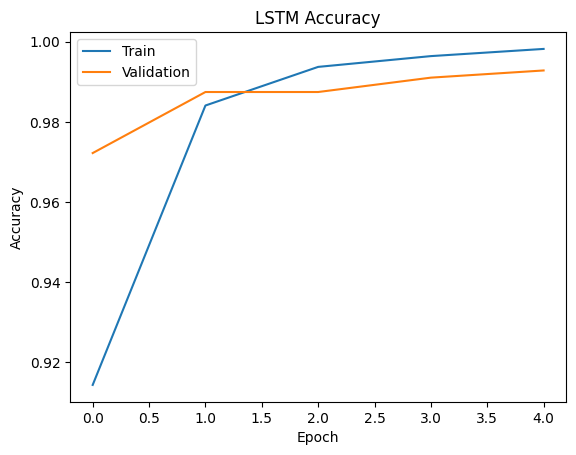

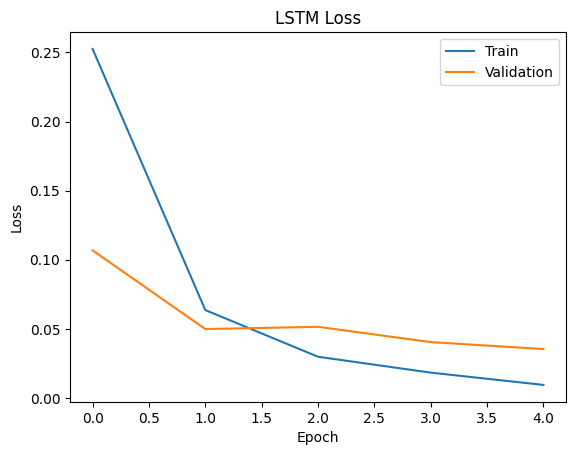

In [106]:
import matplotlib.pyplot as plt

# Accuracy grafiği
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title('LSTM Accuracy')
plt.legend(['Train', 'Validation'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Loss grafiği
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM Loss')
plt.legend(['Train', 'Validation'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# **LSTM Modelinin Değerlendirilmesi**

Eğitilen LSTM modelinin test verisi üzerindeki performansını analiz ediniz.

**👉 Görev:**

Test verisi üzerinde model tahminlerini elde edin

Modelin loss ve accuracy değerlerini hesaplayın

Sonuçları incelemek için confusion matrix oluşturun

In [107]:
loss, accuracy = lstm_model.evaluate(X_test, y_test)

print("LSTM Test Loss:", loss)
print("LSTM Test Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9928 - loss: 0.0354
LSTM Test Loss: 0.03539779409766197
LSTM Test Accuracy: 0.9928250908851624


In [108]:
y_pred_lstm = lstm_model.predict(X_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [109]:
y_pred_lstm = (y_pred_lstm > 0.5).astype(int)

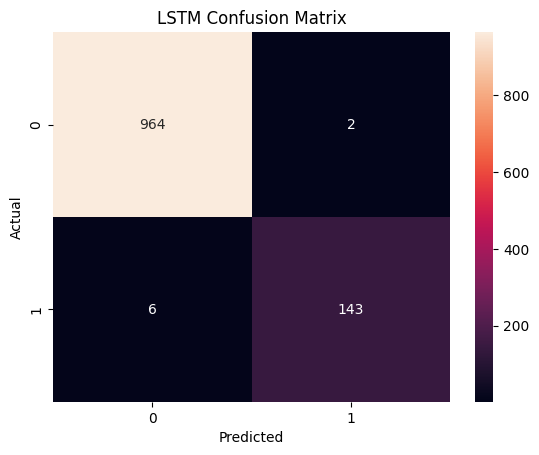

In [110]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lstm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")
plt.show()

LSTM modeli, diğer modellere göre daha iyi performans göstermiştir. Özellikle spam mesajların tespitinde hata sayısının en düşük olduğu gözlemlenmiştir. Bu nedenle en başarılı model olarak LSTM seçilmiştir.